In [1]:
import os
import time
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from gensim.models import KeyedVectors
import torch
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification

nltk.download('stopwords', quiet=True)

DATA_DIR = "./bbc"

dataset = load_files(DATA_DIR, encoding="latin1", decode_error="replace")

X = dataset.data
y = dataset.target
label_names = dataset.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Categories: {label_names}")
print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Categories: ['business', 'entertainment', 'politics', 'sport', 'tech']
Training samples: 1780 | Testing samples: 445


In [2]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_a(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

def preprocess_b(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text.split()

X_train_a = [preprocess_a(txt) for txt in X_train]
X_test_a  = [preprocess_a(txt) for txt in X_test]

X_train_b = [preprocess_b(txt) for txt in X_train]
X_test_b  = [preprocess_b(txt) for txt in X_test]

print("Text preprocessing finished.")

Text preprocessing finished.


In [3]:
vectorizer_bow = CountVectorizer(max_features=5000)
X_train_bow = vectorizer_bow.fit_transform(X_train_a)
X_test_bow = vectorizer_bow.transform(X_test_a)

vectorizer_tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train_a)
X_test_tfidf = vectorizer_tfidf.transform(X_test_a)

model_path = r"C:\Users\Administrator\gensim-data\word2vec-ruscorpora-300\word2vec-ruscorpora-300.gz"
print(f"Loading local Word2vec model from: {model_path}")

w2v_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

def get_average_word2vec(tokens_list, model, vector_size=300):
    if len(tokens_list) < 1:
        return np.zeros(vector_size)
    
    valid_vectors = [model[word] for word in tokens_list if word in model]
    
    if len(valid_vectors) < 1:
        return np.zeros(vector_size)
        
    return np.mean(valid_vectors, axis=0)

X_train_w2v = np.array([get_average_word2vec(tokens, w2v_model) for tokens in X_train_b])
X_test_w2v  = np.array([get_average_word2vec(tokens, w2v_model) for tokens in X_test_b])

print("Feature extraction finished.")

Loading local Word2vec model from: C:\Users\Administrator\gensim-data\word2vec-ruscorpora-300\word2vec-ruscorpora-300.gz
Feature extraction finished.


In [4]:
start_time_all = time.time()

feature_sets = {
    "BoW": (X_train_bow, X_test_bow),
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "Word2vec": (X_train_w2v, X_test_w2v)
}

models = {
    "LogisticRegression": (LogisticRegression(max_iter=1000), {'C': [0.1, 1.0]}),
    "SVM_Linear": (SVC(kernel='linear'), {'C': [0.1, 1.0]}),
    "RandomForest": (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100]})
}

best_traditional_model = None
best_traditional_acc = 0
best_traditional_name = ""
best_traditional_X_test = None

print("Training and tuning traditional classifiers")

for feat_name, (X_tr, X_te) in feature_sets.items():
    print(f"\n--- Feature Representation: {feat_name} ---")
    
    for model_name, (model, param_grid) in models.items():
        step_start_time = time.time()
        
        grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid.fit(X_tr, y_train)
        
        best_clf = grid.best_estimator_
        y_pred = best_clf.predict(X_te)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        train_time = time.time() - step_start_time
        
        print(f"Model: {model_name:<18} | Acc: {acc:.4f} | F1: {f1:.4f} | Time: {train_time:.1f}s | Params: {grid.best_params_}")
        
        if acc > best_traditional_acc:
            best_traditional_acc = acc
            best_traditional_model = best_clf
            best_traditional_name = f"{feat_name} + {model_name}"
            best_traditional_X_test = X_te

total_time = time.time() - start_time_all
print(f"\nCompleted in {total_time:.1f}s.")
print(f"WINNER of Traditional Models: {best_traditional_name} with Accuracy = {best_traditional_acc:.4f}")

Training and tuning traditional classifiers

--- Feature Representation: BoW ---
Model: LogisticRegression | Acc: 0.9640 | F1: 0.9635 | Time: 8.4s | Params: {'C': 0.1}
Model: SVM_Linear         | Acc: 0.9685 | F1: 0.9682 | Time: 8.8s | Params: {'C': 0.1}
Model: RandomForest       | Acc: 0.9596 | F1: 0.9590 | Time: 7.0s | Params: {'n_estimators': 100}

--- Feature Representation: TF-IDF ---
Model: LogisticRegression | Acc: 0.9753 | F1: 0.9748 | Time: 0.5s | Params: {'C': 1.0}
Model: SVM_Linear         | Acc: 0.9730 | F1: 0.9723 | Time: 4.9s | Params: {'C': 1.0}
Model: RandomForest       | Acc: 0.9618 | F1: 0.9608 | Time: 2.2s | Params: {'n_estimators': 100}

--- Feature Representation: Word2vec ---
Model: LogisticRegression | Acc: 0.2315 | F1: 0.0752 | Time: 0.2s | Params: {'C': 0.1}
Model: SVM_Linear         | Acc: 0.2315 | F1: 0.0752 | Time: 1.3s | Params: {'C': 0.1}
Model: RandomForest       | Acc: 0.2315 | F1: 0.0752 | Time: 0.7s | Params: {'n_estimators': 50}

Completed in 34.0s.
W

In [1]:
import os
import urllib.request
import zipfile
import time
import torch
import numpy as np
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

url = "http://mlg.ucd.ie/files/datasets/bbc-fulltext.zip"
zip_path = "bbc-fulltext.zip"
data_dir = "./bbc"

if not os.path.exists(data_dir):
    print("Downloading BBC dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Download and extraction complete.")

print("Loading data...")
dataset = load_files(data_dir, encoding="latin1", decode_error="replace")
X = dataset.data
y = dataset.target
label_names = dataset.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_name = "distilbert-base-uncased"
print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

train_dict = {"text": [str(text) for text in X_train], "label": y_train.tolist()}
test_dict = {"text": [str(text) for text in X_test], "label": y_test.tolist()}

train_dataset = Dataset.from_dict(train_dict).map(tokenize_function, batched=True)
test_dataset = Dataset.from_dict(test_dict).map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Starting GPU Training")
start_time = time.time()
trainer.train()
print(f"Training completed in {time.time() - start_time:.1f} seconds.")

print("Evaluating on test set")
results = trainer.evaluate()
print("\n===============================")
print(f"FINAL BERT RESULTS:")
print(f"Accuracy: {results['eval_accuracy']:.4f}")
print(f"F1-Macro: {results['eval_f1_macro']:.4f}")
print("===============================")

Download and extraction complete.
Loading data...
Loading distilbert-base-uncased...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Starting GPU Training


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.348807,0.156021,0.979775,0.979396
2,0.068075,0.096091,0.979775,0.979273
3,0.038827,0.085286,0.982022,0.981906


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed in 149.8 seconds.
Evaluating on test set



FINAL BERT RESULTS:
Accuracy: 0.9820
F1-Macro: 0.9819


Re-training the Champion Model (TF-IDF + Logistic Regression)
Training Time: 0.1472s | Prediction Time: 0.0010s

--- Classification Report ---
               precision    recall  f1-score   support

     business       0.96      0.96      0.96       115
entertainment       0.99      0.99      0.99        78
     politics       0.96      0.96      0.96        73
        sport       1.00      1.00      1.00       103
         tech       0.96      0.97      0.97        76

     accuracy                           0.98       445
    macro avg       0.97      0.98      0.97       445
 weighted avg       0.98      0.98      0.98       445

Generating Confusion Matrix plot


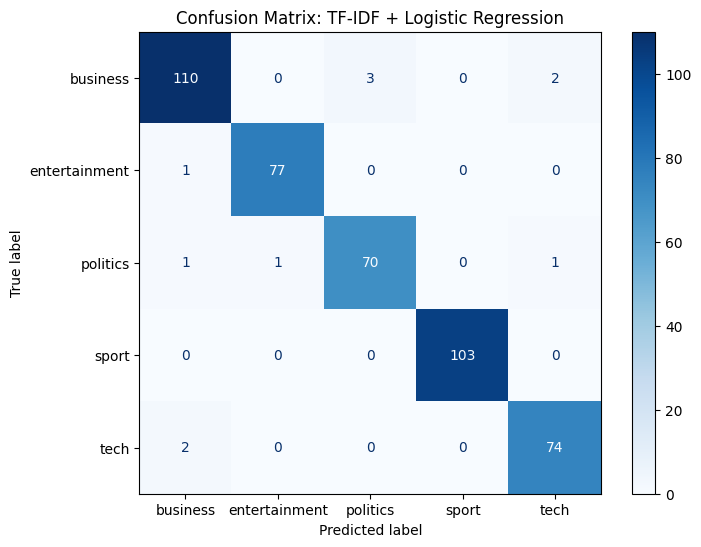


--- Bad Case Analysis (Top 5 Errors) ---

[Error 1]
True Category : entertainment
Predicted As  : business
Text Snippet  : Wal-Mart is sued over rude lyrics  The parents of a 13-year-old girl are suing US supermarket giant Wal-Mart over a CD by rock group Evanescence that contains swear words.  The lawsuit, filed in Washington County, alleges Wal-Mart deceived customers by not putting warning labels on the cover. Trevin...

[Error 2]
True Category : politics
Predicted As  : business
Text Snippet  : EU fraud clampdown urged  EU member states are failing to report fraud and irregularities in EU funds on a consistent basis, the UK's public spending watchdog has said.  The National Audit Office said although the latest figures showed reported fraud was falling, the EU still had no common definitio...

[Error 3]
True Category : politics
Predicted As  : tech
Text Snippet  : Game warnings 'must be clearer'  Violent video games should carry larger warnings so parents can understand what their

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import time

print("Re-training the Champion Model (TF-IDF + Logistic Regression)")
start_train = time.time()
champion_model = LogisticRegression(C=1.0, max_iter=1000)
champion_model.fit(X_train_tfidf, y_train)
train_time = time.time() - start_train

start_pred = time.time()
y_pred = champion_model.predict(X_test_tfidf)
pred_time = time.time() - start_pred

print(f"Training Time: {train_time:.4f}s | Prediction Time: {pred_time:.4f}s")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=label_names))

print("Generating Confusion Matrix plot")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")
plt.show()

print("\n--- Bad Case Analysis (Top 5 Errors) ---")
errors_found = 0
for i in range(len(y_test)):
    if y_test[i] != y_pred[i]:
        true_label = label_names[y_test[i]]
        pred_label = label_names[y_pred[i]]
        
        text_snippet = str(X_test[i]).replace('\n', ' ')
        snippet_display = text_snippet[:300] + "..." if len(text_snippet) > 300 else text_snippet
        
        print(f"\n[Error {errors_found + 1}]")
        print(f"True Category : {true_label}")
        print(f"Predicted As  : {pred_label}")
        print(f"Text Snippet  : {snippet_display}")
        
        errors_found += 1
        if errors_found >= 5:
            break